In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from spectrumlab.spectra import Spectrum

In [4]:
from spectrumlab_emulations.spectra import EmittedSpectrum

In [12]:
alpha = .25

In [13]:
number = np.arange(1000)

In [14]:

index_even = number % 2 == 0
index_odd = number % 2 == 1

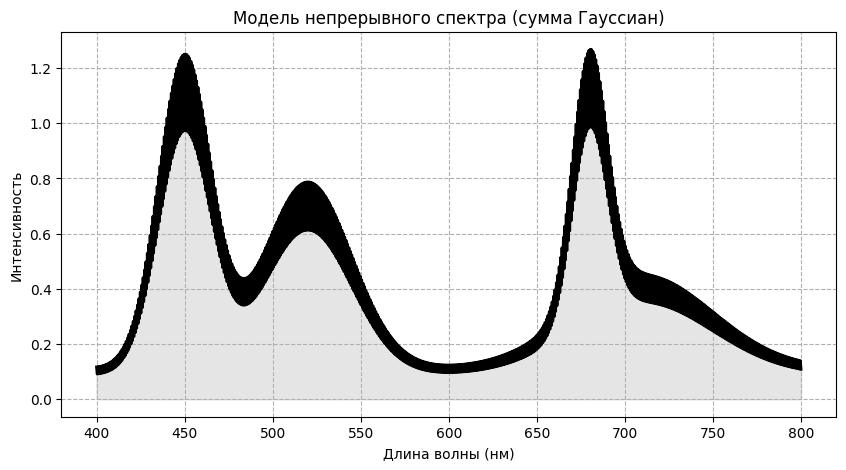

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(400, 800, 1000)  # например, нанометры

params = [
    {"A": 1.0, "mu": 450, "sigma": 15},
    {"A": 0.6, "mu": 520, "sigma": 25},
    {"A": 0.8, "mu": 680, "sigma": 10},
    {"A": 0.3, "mu": 710, "sigma": 40},
]

spectrum = np.zeros_like(x) + .1

for p in params:
    line = p["A"] * np.exp(-((x - p["mu"])**2) / (2 * p["sigma"]**2))
    spectrum += line

spectrum[index_even] = spectrum[index_even] * (1 + alpha/2)
spectrum[index_odd] = spectrum[index_odd] * (1 - alpha/2)


plt.figure(figsize=(10, 5))
plt.plot(x, spectrum, label='Смоделированный спектр', color='black', lw=2)
plt.fill_between(x, spectrum, alpha=0.2, color='gray')
plt.title("Модель непрерывного спектра (сумма Гауссиан)")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Интенсивность")
plt.grid(True, linestyle='--')
plt.show()


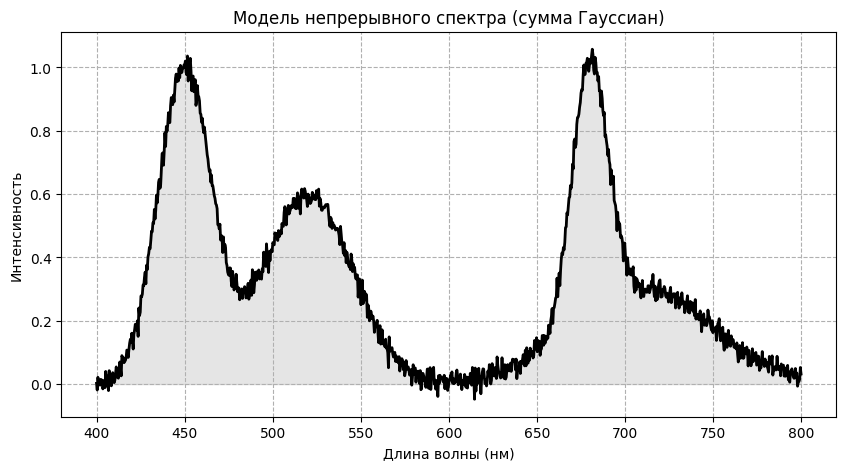

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Параметры области (ось X)
x = np.linspace(400, 800, 1000)  # например, нанометры

# 2. Параметры пиков (амплитуда, центр, ширина)
params = [
    {"A": 1.0, "mu": 450, "sigma": 15},
    {"A": 0.6, "mu": 520, "sigma": 25},
    {"A": 0.8, "mu": 680, "sigma": 10},
    {"A": 0.3, "mu": 710, "sigma": 40},
]

# 3. Генерация спектра
spectrum = np.zeros_like(x)

for p in params:
    # Вычисляем гауссиану для каждого пика
    line = p["A"] * np.exp(-((x - p["mu"])**2) / (2 * p["sigma"]**2))
    spectrum += line

# 4. Добавление небольшого шума (для реалистичности)
noise = np.random.normal(0, 0.02, x.shape)
spectrum += noise

# 5. Визуализация
plt.figure(figsize=(10, 5))
plt.plot(x, spectrum, label='Смоделированный спектр', color='black', lw=2)
plt.fill_between(x, spectrum, alpha=0.2, color='gray')
plt.title("Модель непрерывного спектра (сумма Гауссиан)")
plt.xlabel("Длина волны (нм)")
plt.ylabel("Интенсивность")
plt.grid(True, linestyle='--')
plt.show()
